## Pytorch Workflow

In [1]:
what_we_are_covering={1:"data(prepare and load)",
                      2:"build model",
                      3:"fitting the model to data",
                      4:"making predictions and evaluating a model",
                      5:"saving and loading a model",
                      6:"putting it all together"}
what_we_are_covering                      

{1: 'data(prepare and load)',
 2: 'build model',
 3: 'fitting the model to data',
 4: 'making predictions and evaluating a model',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn # building blocks for neural networks
import matplotlib.pyplot as plt

# check pytorch version
print(torch.__version__)

2.5.1+cu121


### 1. Data (preparing and loading)
Data can be almost anything in machine learning

Machine learning is agme of two parts:
1. Get data into a numerical representations
2. Build a model to learn patterns in that representations

To showcase this lets create some known data using linear regression formula
We will use a linear regression formula to make a straight line known as parameters


In [3]:
#create knwon parameters
weight=0.7
bias=0.3

#Create a linear model
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias

X[:10],y[:10], len(X),len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

### Splitting data in training and testing

In [4]:
#create test and train data
train_split=int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Visualizing the data which sometimes is most important

In [5]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10,7))
    
    #plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    
    #plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    
    if predictions is not None:
        #plot the predictions in red
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
        
    plt.legend(prop={"size":14});

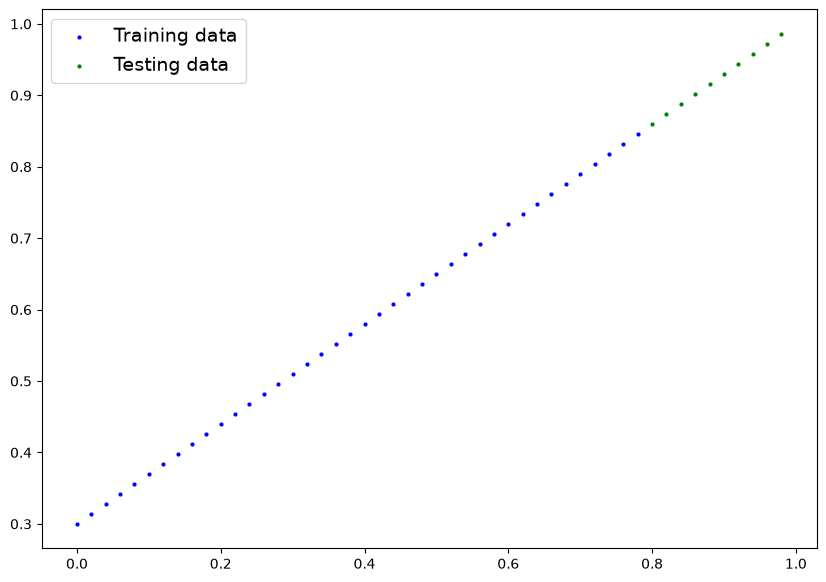

In [6]:
plot_predictions()

## 2. Building our first pytorch model

What our model does:
* Start with random values(weight and bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values(the weight and bias values we used to create the data)

How does it do so?
1. Gradient Descent 
2. Backrpropogation

In [48]:
#create a linear regression model
class LinearRegressionModel(nn.Module): # almost all models in PyTorch inherit from nn.Module
    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.randn(1,requires_grad=True,  # can this parameter be updated during training? yes, requires_grad=True means it will be updated during training
                                              dtype=torch.float))
        self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        
    def forward(self,x:torch.Tensor)->torch.Tensor: # x is input data and the function returns output data
        return self.weights*x+self.bias

### Pytorch model building essentials
* torch.nn- contains all of the buildings for computational graphs( a neural network can be considered a computational graph)
* torch.nn.parameter- what parameters should our model try and learn, often a Pytorch layer from torch.nn will set these for us
* torch.nn.Module- The base class for all neural networks modules , if you subclass it , you should overwrite forward()
* torch.optim- this is where the optimizers in pytorch live, they will help with gradient descent
* def forward- all nn.module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

### Now we have created a model , lets see whats inside
So we can check our model or whats inside our model using .parameters

In [50]:
# create a random seed for reproducibility
torch.manual_seed(42)

# create an instance of the model(this is a subclass of nn.Module)
model_0=LinearRegressionModel()

# check out parameters of the model
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [34]:
# list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [51]:
weight, bias

(0.7, 0.3)

### Making predictions using torch.inference_mode()
To check our model predective power , lets see how will it predicts y_test based on x_test.
When we pass data through our model its going to run it through thr forward() method

In [52]:
y_preds=model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [53]:
# make redictions
with torch.inference_mode(): # inference mode is used to turn off gradients, which reduces memory usage and speeds up computations
    y_preds=model_0(X_test)
y_preds    

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [13]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

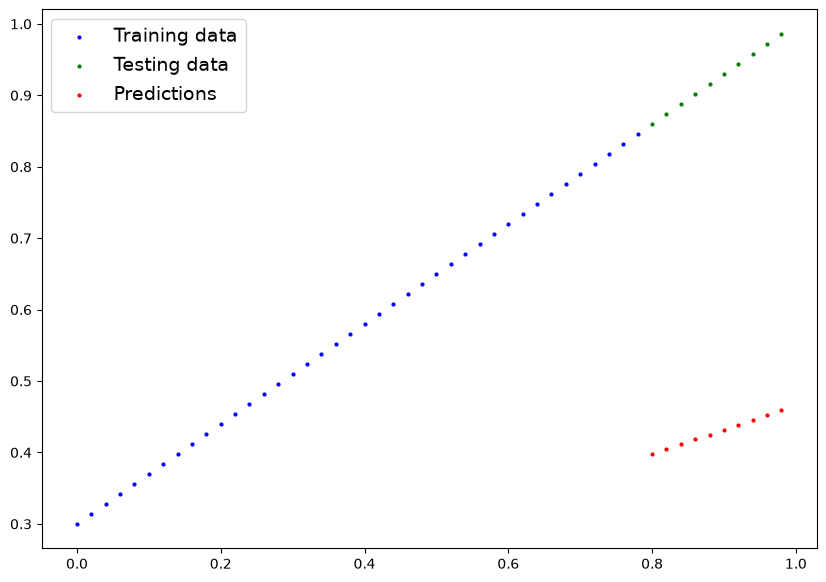

In [14]:
plot_predictions(predictions=y_preds)

## 3. Train model
the whole idea for training a model from some unknown parameters(these may be random) to some known parameters

Or in other words from a poor representation of the data to a better representation of the data

One way to measure how poor or how wrong your model prediction are is to use loss function

Note: loss func can also be called cosst func or criterion

Things we need to train:

**Loss func:** A func to measure how wrong your model's predictions are to the ideal outputs, lower is better.

**optimizers:** Takes into account the loss of a model and adjusts the models parameters(e.g weight & bias) to improvethe loss function.

And specifically for pytorch we need:
* A training loop
* A testing loop

In [15]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [16]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [54]:
#set up a loss function and optimizer
loss_fn=nn.L1Loss() # mean absolute error
optimizer=torch.optim.SGD(params=model_0.parameters(), lr=0.01)

### Building a tarining loop in ptorch

A couple of things we need in training loop:
0. Loop thru data
1. forward pass(this involves data moving thru model 'forward()' functions) to make predictions on data- also called forward propagation
2. calculate the loss 
3. Optimizer zero grad
4. Loss backward- move backwards thru the network to calculate the gradients of each of the paramters of our model with respect to the loss(backpropagation)
5. Optimizer step- use the optimizer to adjust our models parameters to try and improve the loss(gradient descent)

In [55]:
# a epoch is one loop through the data passed to the model in training
epochs=100

# 0. Loop through the data
for epoch in range(epochs):
    # set the model to training mode
    model_0.train() #training mode is used to turn on gradients, which allows the model to learn and update its parameters during training
    
    # 1. Forward pass
    y_pred=model_0(X_train)
    
    # 2. Calculate the loss
    loss=loss_fn(y_pred, y_train)
    print(f"Loss: {loss}")
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()
    
    # 4. Loss backward
    loss.backward()
    
    # 5. Optimizer step(perform gradient descent)
    optimizer.step() # by default, the optimizer will update all parameters in the model that have requires_grad=True
    
    ## Testing
    model_0.eval() # evaluation mode is used to turn off gradients, which reduces memory
    with torch.inference_mode(): # inference mode is used to turn off gradients, which reduces memory usage and speeds up computations
        test_pred=model_0(X_test)

        # calculate the loss
        test_loss=loss_fn(test_pred, y_test)
    if epoch%10==0:
        print(f"Epoch:{epoch} | Loss: {loss} | Test loss: {test_loss}")    

        #print out model state_dict
        print(model_0.state_dict())


    

Loss: 0.31288138031959534
Epoch:0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Loss: 0.3013603389263153
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713240146637
Epoch:10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])
Loss: 0.18615034222602844
Loss: 0.1746293306350708
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912236571312
Loss: 0.09681284427642822
Loss: 0.08908725529909134
Epoch:20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])
Loss: 0.08227583020925522
Loss: 0.07

In [56]:
with torch.inference_mode():
    y_preds=model_0(X_test)

In [57]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [31]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [58]:
weight, bias

(0.7, 0.3)

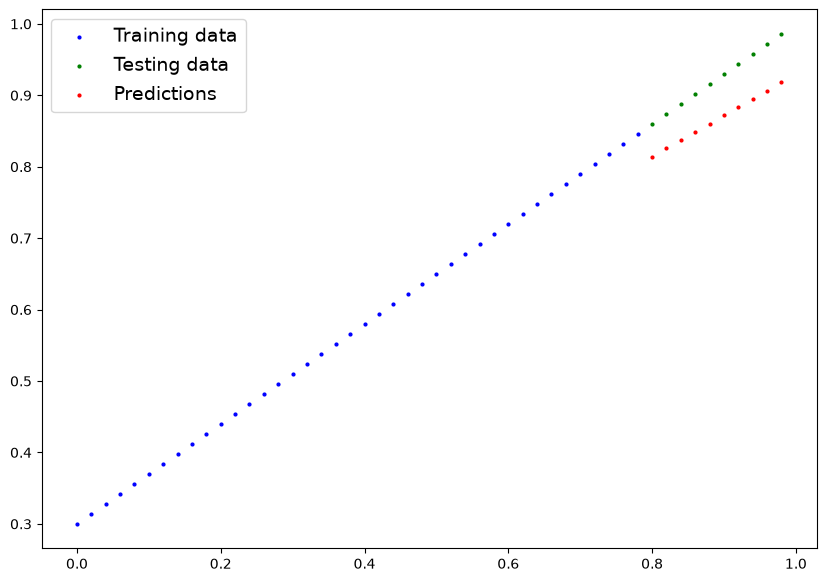

In [59]:
plot_predictions(predictions=y_preds);